# Binary Classification with the Perceptron Algorithm

This project implements the Perceptron algorithm from scratch using NumPy and applies it to a binary classification task on a high-dimensional dataset of 16,000 samples with 128 features. The model is evaluated using 5-fold cross-validation on both the original 128-feature space and a Haar wavelet-reduced 4-feature space.

In [1]:
import numpy as np

## 1. Perceptron Implementation

The Perceptron is a simple linear binary classifier that learns a decision boundary by iteratively updating weights based on misclassified samples. The implementation includes data loading, row shuffling, the Perceptron class with fit and transform methods, and 5-fold cross-validation.

In [2]:
def load_data(file_path: str) -> tuple[np.ndarray, np.ndarray]:
    """
    Load the dataset, return features and labels.
    Args:
        file_path: str, path to the data file
    Returns:
        X: numpy array of shape (n_samples, n_features)
        y: numpy array of shape (n_samples,)
    """
    X = np.loadtxt(file_path, delimiter = None)
    y = np.array([0] * 8000 + [1] * 8000)
    return X, y
# load the dataset
data, labels = load_data('../data/data.txt')


In [3]:
def shuffle_rows(X: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Shuffle the rows of the input matrix X.
    Args:
        X: data, numpy array of shape (n_samples, n_features)
        y: class labels, numpy array of shape (n_samples,)
    Returns:
        X_shuffled: numpy array of shape (n_samples, n_features) with shuffled rows
        y_shuffled: numpy array of shape (n_samples,) with shuffled labels
    """
    X_shuffled = X.copy()
    y_shuffled = y.copy()
    
    orderofrows = list(range(len(X)))
    np.random.shuffle(orderofrows)
    
    X_shuffled = X_shuffled[orderofrows]
    y_shuffled = y_shuffled[orderofrows]
    return X_shuffled, y_shuffled

# Example usage:
X, y = load_data('../data/data.txt')
X_shuffled, y_shuffled = shuffle_rows(X, y)

In [4]:
class Perceptron:
    """
    The template for the Perceptron class.
    This class should implement the perceptron algorithm for binary classification.

    You must implement the provided methods.

    You may add additional methods or attributes as needed.

    Note: This implementation contains more than one bug. Please read it carefully and resolve them as much as possible. 
          The test cases at the end of this notebook are trivial, so you may observe that the test cases are passing, 
          but the implementation may still be incorrect.
    """

    def __init__(self, lr: float, max_iter: int, gamma: float):
        """
        Initialize the perceptron with learning rate and maximum iterations.
        Args:
            lr: float, learning rate
            max_iter: int, maximum number of iterations
            gamma: float, error threshold, used to determine if the model is converged
        """
        self.lr = lr
        self.max_iter = max_iter
        self.gamma = gamma
        self.w = None
        self.bias = None
        self._last_iters = 0

    def fit(self, X: np.ndarray, y: np.ndarray):
        """
        Train the perceptron on the training data.
        Args:
            X: numpy array of shape (n_samples, n_features), training data
            y: numpy array of shape (n_samples,), class labels
        """
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features, dtype=float)
        self.bias = 0.0

        self._last_iters = 0
        for it in range(1, self.max_iter + 1):
            for index in range(n_samples):
                score = X[index] @ self.w + self.bias
                label = 1 if score >= 0 else 0
                if label != y[index]:
                    error = y[index] - label
                    self.w += self.lr * error * X[index]
                    self.bias += self.lr * error
            allscores = X @ self.w + self.bias
            alllabels = (allscores >= 0).astype(int)
            err_rate = (alllabels != y).mean()
            
            self._last_iters = it
            if err_rate <= self.gamma:
                break

    def transform(self, X: np.ndarray) -> np.ndarray:
        """
        Predict class labels for the input data.
        Args:
            X: numpy array of shape (n_samples, n_features), input data
        Returns:
            y_pred: numpy array of shape (n_samples,), predicted class labels
        """
        scores = X @ self.w + self.bias
        y_pred = (scores >= 0).astype(int)
        return y_pred

    def get_converging_iterations(self) -> int:
        return int(self._last_iters)


# Example usage:
#perceptron = Perceptron(lr=0.01, max_iter=1000)
#perceptron.fit(X_train, y_train)
#y_pred = perceptron.transform(X_test)

In [5]:
def cross_validation(X: np.ndarray, y: np.ndarray, k: int = 5) -> list[tuple[float, int]]:
    """
    Perform k-fold cross-validation on the dataset.

    Args:
        X: numpy array of shape (n_samples, n_features), data
        y: numpy array of shape (n_samples,), class labels
        k: int, number of folds for cross-validation
    Returns:
        result: list of tuples of length k, each containing (accuracy, iterations) for each fold
    """
    n_samples = X.shape[0]
    if n_samples != y.shape[0]:
        raise ValueError("X and y must have the same number of samples")

    # Shuffle indices for folds
    indices = np.random.permutation(n_samples)
    folds = np.array_split(indices, k)

    results: list[tuple[float, int]] = []
    for i in range(k):
        
        model = Perceptron(lr=0.01, max_iter=1000, gamma=0.1)
        
        val_idx = folds[i]
        train_idx = np.setdiff1d(indices, val_idx, assume_unique=False)

        X_train, y_train = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx], y[val_idx]

        model.fit(X_train, y_train)
        y_pred = model.transform(X_val)
        acc = float((y_pred == y_val).mean())
        iters = model.get_converging_iterations()
        results.append((acc, iters))

    return results


# Example usage:
#results = cross_validation(X, y, k=5)
#for accuracy, iterations in results:
#    print(f'Accuracy: {accuracy:.2f}, Iterations: {iterations}')

In [6]:
def haar_matrix(n: int) -> np.ndarray:
    """
    Generate an n x n Haar matrix recursively.
    The Haar matrix is a square matrix used in wavelet transforms.

    Args:
        n: int, size of the Haar matrix (must be a power of 2)
    Returns:
        H: numpy array of shape (n, n), Haar matrix
    """
    if n == 1:
        return np.array([[1]])
    H = haar_matrix(n // 2)
    top = np.kron(H, np.array([[1.0, 1.0]]))
    bottom = np.kron(np.eye(len(H)), [1, -1])
    return np.vstack((top, bottom))

def wavelet_transform(X: np.ndarray, haar_n: int, reduced_n: int) -> np.ndarray:
    """
    Apply Haar wavelet transform to X using an n x n Haar matrix.
    Args:
        X: numpy array of shape (n_samples, n_features)
        haar_n: int, number of features (should match X.shape[1])
        reduced_n: int, number of features to reduce to after transformation
    Returns:
        X_wavelet: numpy array of shape (n_samples, n_features)
    """
    H = haar_matrix(haar_n)
    norm_factor = np.count_nonzero(H, axis=1)  # Normalization factor
    X_wavelet = np.dot(X, H.T) / norm_factor
    return X_wavelet[:, :reduced_n]

# Example usage:
X_wavelet = wavelet_transform(X, haar_n=X.shape[1], reduced_n=10)
print(X_wavelet.shape)  # Should be (n_samples, reduced_n)

(16000, 10)


## 2. Cross-Validation Analysis

The Perceptron is evaluated using 5-fold cross-validation on two versions of the dataset:
- **128 features** — the original full-dimensional space
- **4 features** — reduced using Haar wavelet transform

This comparison shows how dimensionality reduction affects classification accuracy and convergence speed.

128-D Results:
Fold 1: Accuracy:99.5%, Iterations to converge: 1
Fold 2: Accuracy:99.8%, Iterations to converge: 1
Fold 3: Accuracy:99.8%, Iterations to converge: 1
Fold 4: Accuracy:99.8%, Iterations to converge: 1
Fold 5: Accuracy:99.8%, Iterations to converge: 1

4-D Results:
Fold 1: Accuracy:93.0%, Iterations to converge: 1
Fold 2: Accuracy:97.0%, Iterations to converge: 1
Fold 3: Accuracy:97.2%, Iterations to converge: 1
Fold 4: Accuracy:96.3%, Iterations to converge: 1
Fold 5: Accuracy:96.6%, Iterations to converge: 1

Comparative Analysis:
Original 128 features: Avg Accuracy = 99.7%, Avg Iterations = 1.0
Reduced  4  features:  Avg Accuracy = 96.0%, Avg Iterations = 1.0


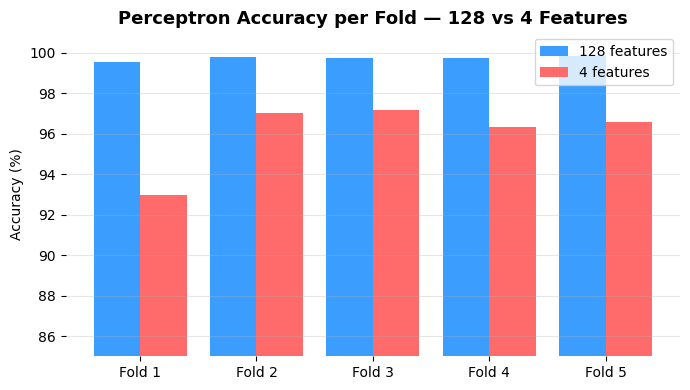

In [7]:
import os
import matplotlib.pyplot as plt

os.makedirs('plots', exist_ok=True)
np.random.seed(20)
X, y = load_data('../data/data.txt')
X_shuffled, y_shuffled = shuffle_rows(X, y)

print('128-D Results:')
dimension128features = cross_validation(X_shuffled, y_shuffled, k=5)
for i, (accuracy, iterations) in enumerate(dimension128features):
    print(f'Fold {i+1}: Accuracy:{accuracy:.1%}, Iterations to converge: {iterations}')

print('\n4-D Results:')
Xwavelet = wavelet_transform(X_shuffled, haar_n=128, reduced_n=4)
dimension4features = cross_validation(Xwavelet, y_shuffled, k=5)
for i, (accuracy, iterations) in enumerate(dimension4features):
    print(f'Fold {i+1}: Accuracy:{accuracy:.1%}, Iterations to converge: {iterations}')

avg_acc_128 = sum(a for a, _ in dimension128features) / len(dimension128features)
avg_acc_4   = sum(a for a, _ in dimension4features)   / len(dimension4features)
avg_iter_128 = sum(it for _, it in dimension128features) / len(dimension128features)
avg_iter_4   = sum(it for _, it in dimension4features)   / len(dimension4features)

print(f'\nComparative Analysis:')
print(f'Original 128 features: Avg Accuracy = {avg_acc_128:.1%}, Avg Iterations = {avg_iter_128:.1f}')
print(f'Reduced  4  features:  Avg Accuracy = {avg_acc_4:.1%}, Avg Iterations = {avg_iter_4:.1f}')

# Bar chart — Accuracy comparison
fig, ax = plt.subplots(figsize=(7, 4))
folds = [f'Fold {i+1}' for i in range(5)]
acc_128 = [a * 100 for a, _ in dimension128features]
acc_4   = [a * 100 for a, _ in dimension4features]
x = range(5)
ax.bar([i - 0.2 for i in x], acc_128, width=0.4, label='128 features', color='#3b9eff', edgecolor='none')
ax.bar([i + 0.2 for i in x], acc_4,   width=0.4, label='4 features',   color='#ff6b6b', edgecolor='none')
ax.set_xticks(list(x))
ax.set_xticklabels(folds)
ax.set_title('Perceptron Accuracy per Fold — 128 vs 4 Features', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim([85, 101])
ax.legend()
ax.spines[:].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Verification

The cells below verify each function against known expected outputs to confirm correctness.

In [8]:
import unittest

In [9]:
# data
X_eval = np.array([
    [1, 2, 3, 4, 0, 0, 0, 0],
    [2, 2, 3, 4, 0, 0, 0, 0],
    [3, 2, 3, 4, 0, 0, 0, 0],
    [4, 2, 3, 4, 0, 0, 0, 0],
    [0, 0, 0, 0, 5, 6, 7, 8],
    [0, 0, 0, 0, 6, 6, 7, 8],
    [0, 0, 0, 0, 7, 6, 7, 8],
    [0, 0, 0, 0, 8, 6, 7, 8]
])

X_val = np.array([
    [1, 1, 3, 4, 0, 0, 0, 0],
    [0, 0, 0, 0, 5, 5, 7, 8],
    [2, 2, 3, 4, 0, 0, 0, 0],
    [0, 0, 0, 0, 6, 6, 8, 8]
])

labels_eval = np.array([0, 0, 0, 0, 1, 1, 1, 1])
labels_val = np.array([0, 1, 0, 1])

In [10]:
class TestPerceptron(unittest.TestCase):
    def setUp(self):
        try:
            self.perceptron = Perceptron(lr=0.01, max_iter=1000, gamma=0.1)
        except (NameError, NotImplementedError):
            self.skipTest("Perceptron not implemented")
        try:
            self.X_train, self.y_train = shuffle_rows(X_eval, labels_eval)
            self.X_val, self.y_val = shuffle_rows(X_val, labels_val)
        except NotImplementedError:
            self.skipTest("shuffle_rows not implemented")

    def test_transform(self):
        try:
            self.perceptron.fit(self.X_train, self.y_train)
        except NotImplementedError:
            self.skipTest("Perceptron.fit not implemented")
        try:
            y_pred = self.perceptron.transform(self.X_val)
        except NotImplementedError:
            self.skipTest("Perceptron.transform not implemented")
        self.assertEqual(y_pred.shape[0], self.X_val.shape[0])
        self.assertTrue(np.all(np.isin(y_pred, [0, 1])))

    def test_cross_validation(self):
        try:
            results = cross_validation(self.X_train, self.y_train, k=2)
        except NotImplementedError:
            self.skipTest("cross_validation not implemented")
        self.assertEqual(len(results), 2)
        for accuracy, iterations in results:
            self.assertGreaterEqual(accuracy, 0.0)
            self.assertLessEqual(accuracy, 1.0)
            self.assertGreater(iterations, 0)

In [11]:
class TestShuffleRows(unittest.TestCase):
    def test_shuffle_alignment_and_permutation(self):
        try:
            X_shuffled, y_shuffled = shuffle_rows(X_eval, labels_eval)
        except NotImplementedError:
            self.skipTest("shuffle_rows not implemented")
        self.assertEqual(X_shuffled.shape, X_eval.shape)
        self.assertEqual(y_shuffled.shape, labels_eval.shape)
        self.assertEqual(set(map(tuple, X_shuffled)), set(map(tuple, X_eval)))
        self.assertEqual(set(y_shuffled.tolist()), set(labels_eval.tolist()))
        original_pairs = list(zip(map(tuple, X_eval), labels_eval.tolist()))
        shuffled_pairs = list(zip(map(tuple, X_shuffled), y_shuffled.tolist()))
        self.assertCountEqual(original_pairs, shuffled_pairs)

In [12]:
class TestPerceptronOutputTypes(unittest.TestCase):
    def test_transform_output_type(self):
        try:
            model = Perceptron(lr=0.01, max_iter=10, gamma=0.0)
        except NotImplementedError:
            self.skipTest("Perceptron.__init__ not implemented")
        X_small = X_eval[:2]
        y_small = labels_eval[:2]
        try:
            model.fit(X_small, y_small)
        except NotImplementedError:
            self.skipTest("Perceptron.fit not implemented")
        try:
            y_pred = model.transform(X_small)
        except NotImplementedError:
            self.skipTest("Perceptron.transform not implemented")
        self.assertIsInstance(y_pred, np.ndarray)
        self.assertEqual(y_pred.dtype.kind in {"b", "i", "u"}, True)
        self.assertEqual(y_pred.shape, (X_small.shape[0],))


In [13]:
class TestPerceptronSeparable(unittest.TestCase):
    def test_linearly_separable_converges(self):
        try:
            model = Perceptron(lr=0.01, max_iter=1000, gamma=0.0)
        except NotImplementedError:
            self.skipTest("Perceptron.__init__ not implemented")
        rng = np.random.default_rng(42)
        class0 = rng.normal(loc=-0.5, scale=0.5, size=(50, 10))
        class1 = rng.normal(loc=0.5, scale=0.5, size=(50, 10))
        X = np.vstack((class0, class1))
        y = np.array([0] * 50 + [1] * 50)

        X_test = rng.normal(loc=-0.5, scale=0.5, size=(50, 10))
        y_test = np.array([0] * 50)
        try:
            model.fit(X, y)
        except NotImplementedError:
            self.skipTest("Perceptron.fit not implemented")
        try:
            y_pred = model.transform(X_test)
        except NotImplementedError:
            self.skipTest("Perceptron.transform not implemented")
        accuracy = (y_pred == y_test).mean()
        self.assertGreaterEqual(accuracy, 0.9)


In [14]:
# run the test suite
unittest.main(argv=[''], verbosity=2, exit=False)


test_cross_validation (__main__.TestPerceptron.test_cross_validation) ... ok
test_transform (__main__.TestPerceptron.test_transform) ... ok
test_transform_output_type (__main__.TestPerceptronOutputTypes.test_transform_output_type) ... ok
test_linearly_separable_converges (__main__.TestPerceptronSeparable.test_linearly_separable_converges) ... ok
test_shuffle_alignment_and_permutation (__main__.TestShuffleRows.test_shuffle_alignment_and_permutation) ... ok

----------------------------------------------------------------------
Ran 5 tests in 0.007s

OK
